# Performance

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
class Model:

    def __init__(self, df):
        self.df = df.copy()
        self.df[['week', 'canton']] = self.df['week_canton'].str.rsplit('-', n=1, expand=True)[[0, 1]]
        self.df.drop(columns = ["week_canton"], inplace = True)
        self.df_act = self.df.drop(columns = ["pred"])
        self.df_pred = self.df.drop(columns = ["actual"])
        self.week_ord = self.df['week'].unique()
        self.df['week'] = pd.Categorical(self.df['week'], categories=self.week_ord, ordered=True)
        self.df_act_pivot = self.df.pivot(index='week', columns='canton', values='actual').reset_index()
        self.df_pred_pivot = self.df.pivot(index='week', columns='canton', values='pred').reset_index()
        try:
            self.df_act_pivot["total"] = self.df_act_pivot.drop(columns="week").sum(axis=1)
            self.df_pred_pivot["total"] = self.df_pred_pivot.drop(columns="week").sum(axis=1)
        except:
            pass

    def ticks_years(self, ax, n):
        [l.set_visible(False) for (i,l) in enumerate(ax.xaxis.get_ticklabels()) if i % n != 0]
        for i, tick in enumerate(ax.xaxis.get_major_ticks()):
            if i % n != 0:
                tick.tick1line.set_visible(False)
                tick.tick2line.set_visible(False)
                tick.gridline.set_visible(False) 

    def plot_total(self):
        metric = ((self.df_act_pivot["total"] - self.df_pred_pivot["total"])**2).mean()
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.plot(self.df_act_pivot['week'], self.df_act_pivot['total'], label='Reales', marker='o')
        ax.plot(self.df_pred_pivot['week'], self.df_pred_pivot['total'], label='Predichos', marker='o')
        self.ticks_years(ax, 10)
        ax.set_xlabel('Week')
        ax.set_ylabel('Casos')

        ax.text(0.93, 0.8, f'MSE: {metric:.2f}', transform=ax.transAxes, ha='center', fontsize=12)
        ax.text(0.93, 0.75, f'RMSE: {metric**0.5:.2f}', transform=ax.transAxes, ha='center', fontsize=12)

        ax.legend()
        ax.set_title('Casos de dengue por semana predichos vs reales para todo el país')
    
    def calculate_metrics(self, var_type):
        cols = self.df_act_pivot.columns[1:-1]
        if var_type == "reg":
            mse_canton = ((self.df_act_pivot[cols] - self.df_pred_pivot[cols])**2).mean()
            mse_canton = mse_canton.sort_values(ascending=False)
            return mse_canton
        else:
            metric_canton = (self.df_act_pivot[cols] == self.df_pred_pivot[cols]).mean() * 100
            metric_canton = metric_canton.sort_values(ascending=False)
            return metric_canton
    
    def get_tops(self, var_type):
        if var_type == "reg":
            mse_canton = self.calculate_metrics("reg")
            head_5 = mse_canton.head(6).keys()
            mse_head_5 = mse_canton.head(6).values
            tail_5 = mse_canton.tail(6).keys()
            mse_tail_5 = mse_canton.tail(6).values
            return head_5, mse_head_5, tail_5, mse_tail_5
        else:   
            metric_canton = self.calculate_metrics("classi")
            head_5 = metric_canton.head(6).keys()
            metric_head_5 = metric_canton.head(6).values
            tail_5 = metric_canton.tail(6).keys()
            metric_tail_5 = metric_canton.tail(6).values
            return head_5, metric_head_5, tail_5, metric_tail_5

    def ticks_years_top(self, x, y, ax, n):
        [l.set_visible(False) for (i,l) in enumerate(ax[x, y].xaxis.get_ticklabels()) if i % n != 0]
        for i, tick in enumerate(ax[x, y].xaxis.get_major_ticks()):
            if i % n != 0:
                tick.tick1line.set_visible(False)
                tick.tick2line.set_visible(False)
                tick.gridline.set_visible(False) 

    def top_graphs_reg(self, x, y, ax, canton, mse):
        ax[x, y].plot(self.df_act_pivot['week'], self.df_act_pivot[canton], label='Reales', marker='o')
        ax[x, y].plot(self.df_pred_pivot['week'], self.df_pred_pivot[canton], label='Predichos', marker='o')
        self.ticks_years_top(x, y, ax, 20)
        ax[x, y].set_xlabel('Week')
        ax[x, y].set_ylabel('Casos')
        ax[x, y].text(0.9, 0.75, f'MSE: {mse:.2f}', transform=ax[x, y].transAxes, ha='center', fontsize=12)
        ax[x, y].text(0.9, 0.68, f'RMSE: {mse**0.5:.2f}', transform=ax[x, y].transAxes, ha='center', fontsize=12)
        ax[x, y].legend()
        ax[x, y].set_title(canton)

    def plot_top_graphs_reg(self):
        head_5, mse_head_5, tail_5, mse_tail_5 = self.get_tops("reg")
        fig, ax = plt.subplots(3, 2, figsize=(14, 14))
        self.top_graphs_reg(0, 0, ax, head_5[0], mse_head_5[0])
        self.top_graphs_reg(0, 1, ax, head_5[1], mse_head_5[0])
        self.top_graphs_reg(1, 0, ax, head_5[2], mse_head_5[0])
        self.top_graphs_reg(1, 1, ax, head_5[3], mse_head_5[0])
        self.top_graphs_reg(2, 0, ax, head_5[4], mse_head_5[0])
        self.top_graphs_reg(2, 1, ax, head_5[5], mse_head_5[0])

        fig.suptitle('Casos de dengue por semana predichos vs reales para los cantones con peor desempeño', fontsize=16)
        
        fig.tight_layout()    

        fig, ax = plt.subplots(3, 2, figsize=(14, 14))

        self.top_graphs_reg(0, 0, ax, tail_5[0], mse_tail_5[0])
        self.top_graphs_reg(0, 1, ax, tail_5[1], mse_tail_5[0])
        self.top_graphs_reg(1, 0, ax, tail_5[2], mse_tail_5[0])
        self.top_graphs_reg(1, 1, ax, tail_5[3], mse_tail_5[0])
        self.top_graphs_reg(2, 0, ax, tail_5[4], mse_tail_5[0])
        self.top_graphs_reg(2, 1, ax, tail_5[5], mse_tail_5[0])
        
        fig.suptitle('Casos de dengue por semana predichos vs reales para los cantones con mejor desempeño', fontsize=16)
        
        fig.tight_layout()
    
    def top_graphs_classi(self, x, y, ax, canton, metric):
        cnf_matrix_canton = confusion_matrix(self.df_act_pivot[canton], self.df_pred_pivot[canton])

        disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matrix_canton)
        disp.plot(ax=ax[x, y], cmap="Blues")
        ax[x, y].set_title(f"{canton} - Aciertos: {metric:.2f}%", pad=20)
        
    def plot_top_graphs_classi(self):
        head_5, mse_head_5, tail_5, mse_tail_5 = self.get_tops("classi")
        fig, ax = plt.subplots(3, 2, figsize=(14, 14))
        self.top_graphs_classi(0, 0, ax, head_5[0], mse_head_5[0])
        self.top_graphs_classi(0, 1, ax, head_5[1], mse_head_5[0])
        self.top_graphs_classi(1, 0, ax, head_5[2], mse_head_5[0])
        self.top_graphs_classi(1, 1, ax, head_5[3], mse_head_5[0])
        self.top_graphs_classi(2, 0, ax, head_5[4], mse_head_5[0])
        self.top_graphs_classi(2, 1, ax, head_5[5], mse_head_5[0])

        fig.suptitle('Casos de dengue por semana predichos vs reales para los cantones con peor desempeño', fontsize=16)
        
        fig.tight_layout()    

        fig, ax = plt.subplots(3, 2, figsize=(14, 14))

        self.top_graphs_classi(0, 0, ax, tail_5[0], mse_tail_5[0])
        self.top_graphs_classi(0, 1, ax, tail_5[1], mse_tail_5[0])
        self.top_graphs_classi(1, 0, ax, tail_5[2], mse_tail_5[0])
        self.top_graphs_classi(1, 1, ax, tail_5[3], mse_tail_5[0])
        self.top_graphs_classi(2, 0, ax, tail_5[4], mse_tail_5[0])
        self.top_graphs_classi(2, 1, ax, tail_5[5], mse_tail_5[0])
        
        fig.suptitle('Casos de dengue por semana predichos vs reales para los cantones con mejor desempeño', fontsize=16)
        
        fig.tight_layout()
    
    def plot_all(self, var_type):
        if var_type == "classi":
            self.plot_top_graphs_classi()
        else: 
            
            self.plot_total()
            self.plot_top_graphs_reg()

# Case numbers

## Linear regression

AttributeError: 'Model' object has no attribute 'top_graphs'

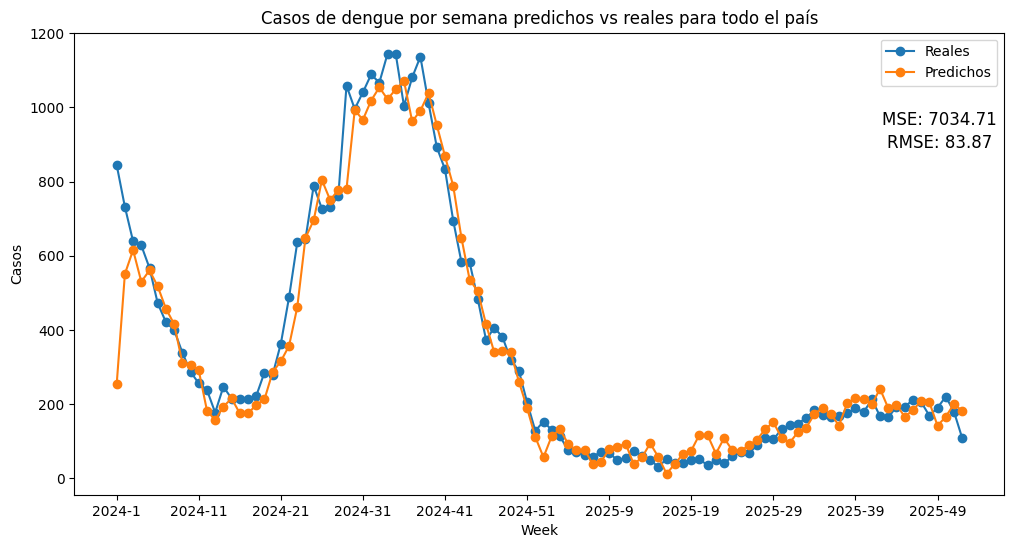

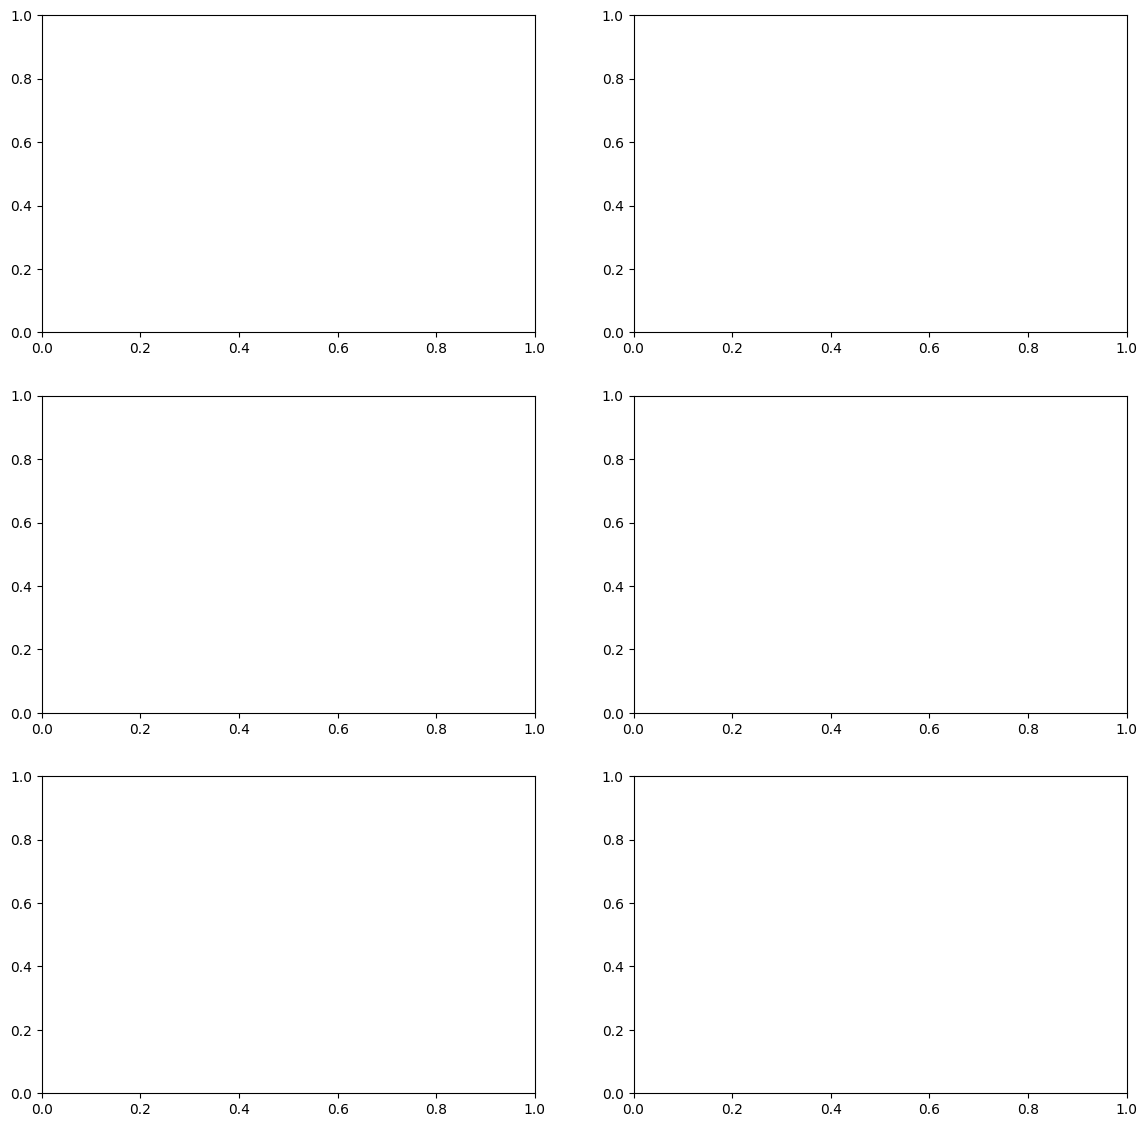

In [32]:
cases_reg_df = pd.read_csv("../../data/model_results/results_cases_reg.csv")
cases_reg_df.drop(columns = ["Unnamed: 0"], inplace = True)

cases_reg = Model(cases_reg_df)

cases_reg.plot_all("reg")

## Random Forest

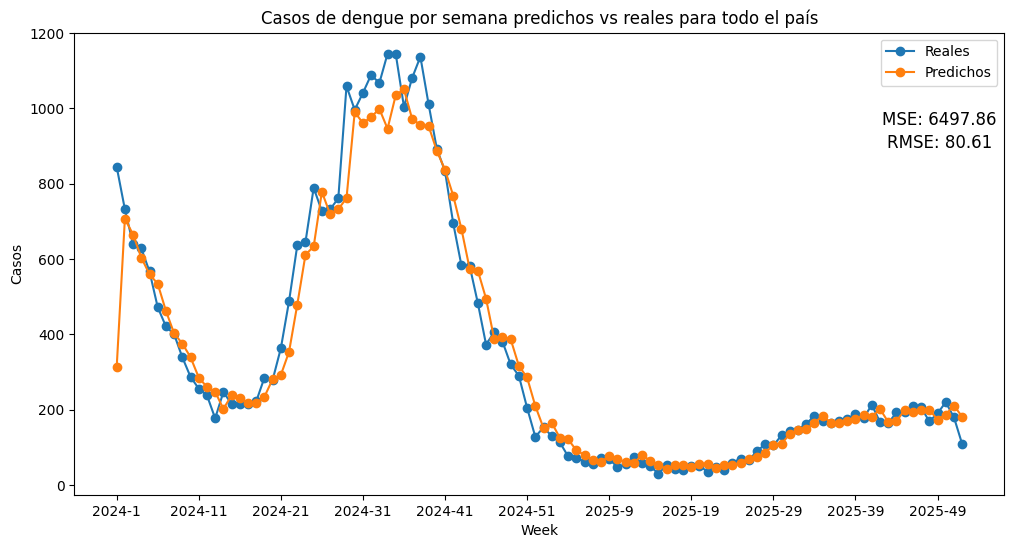

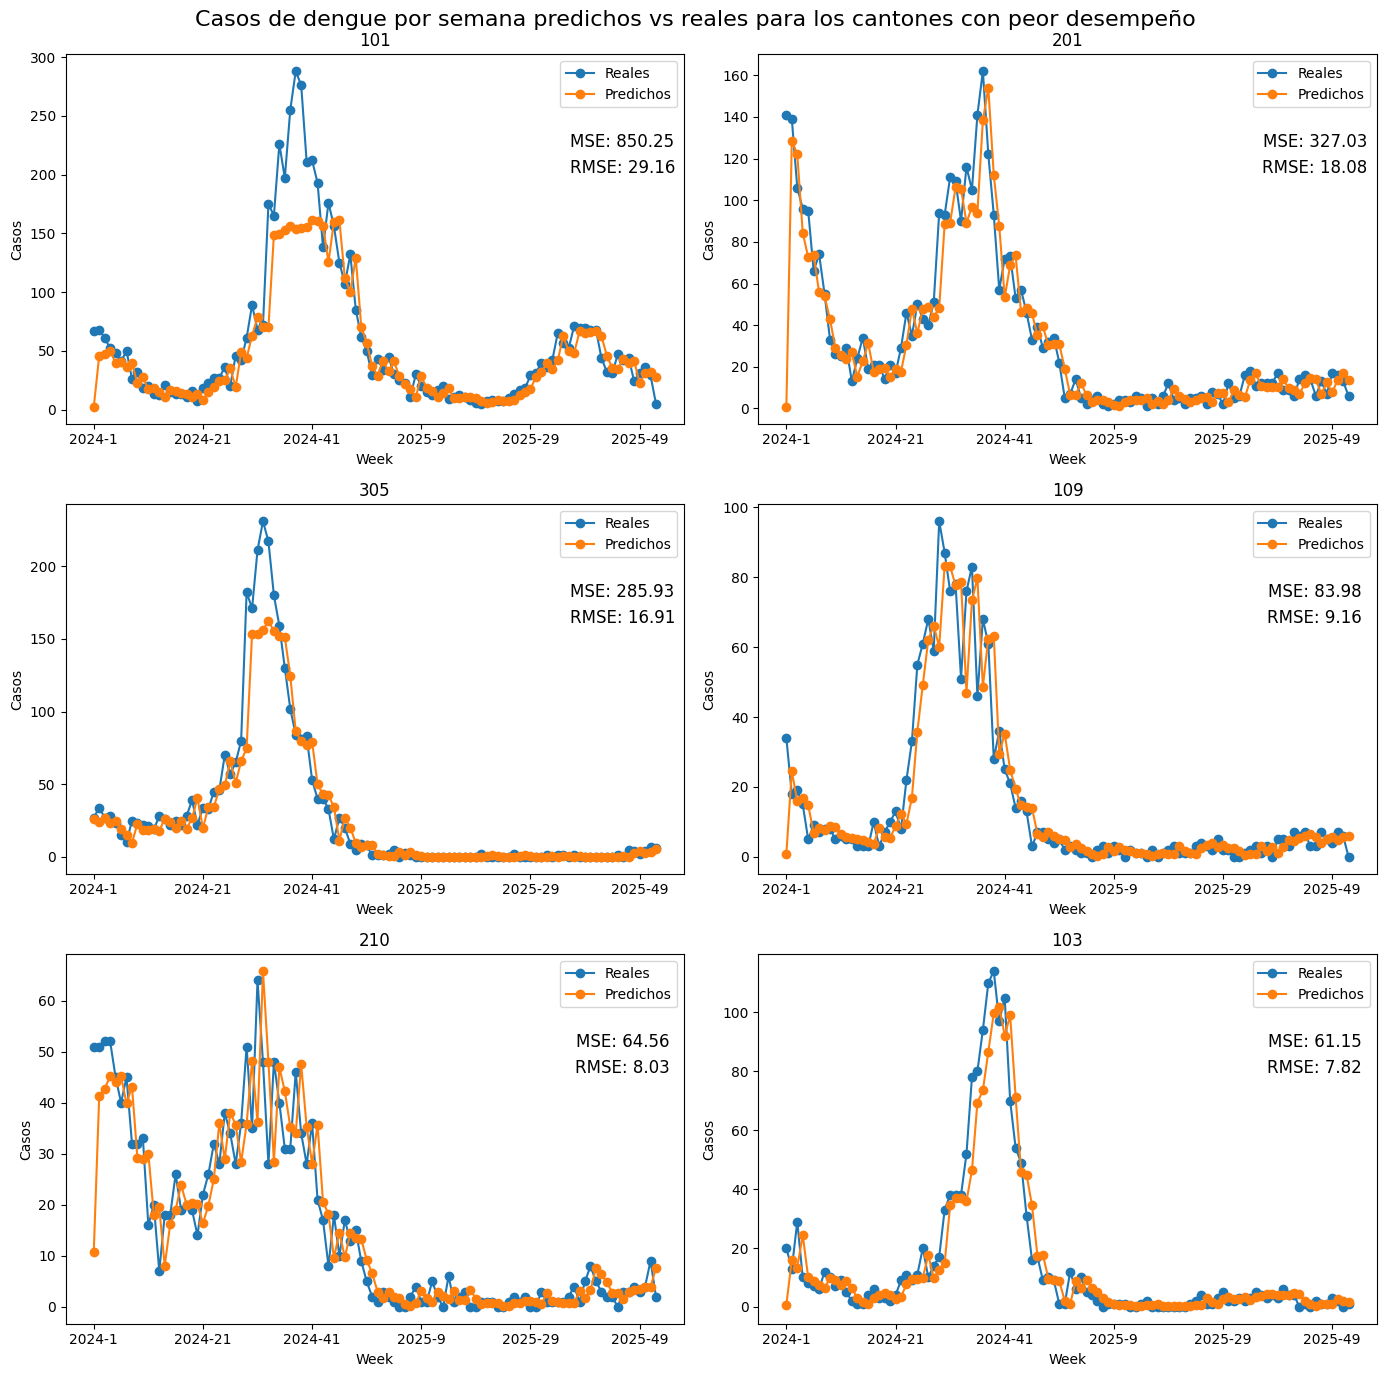

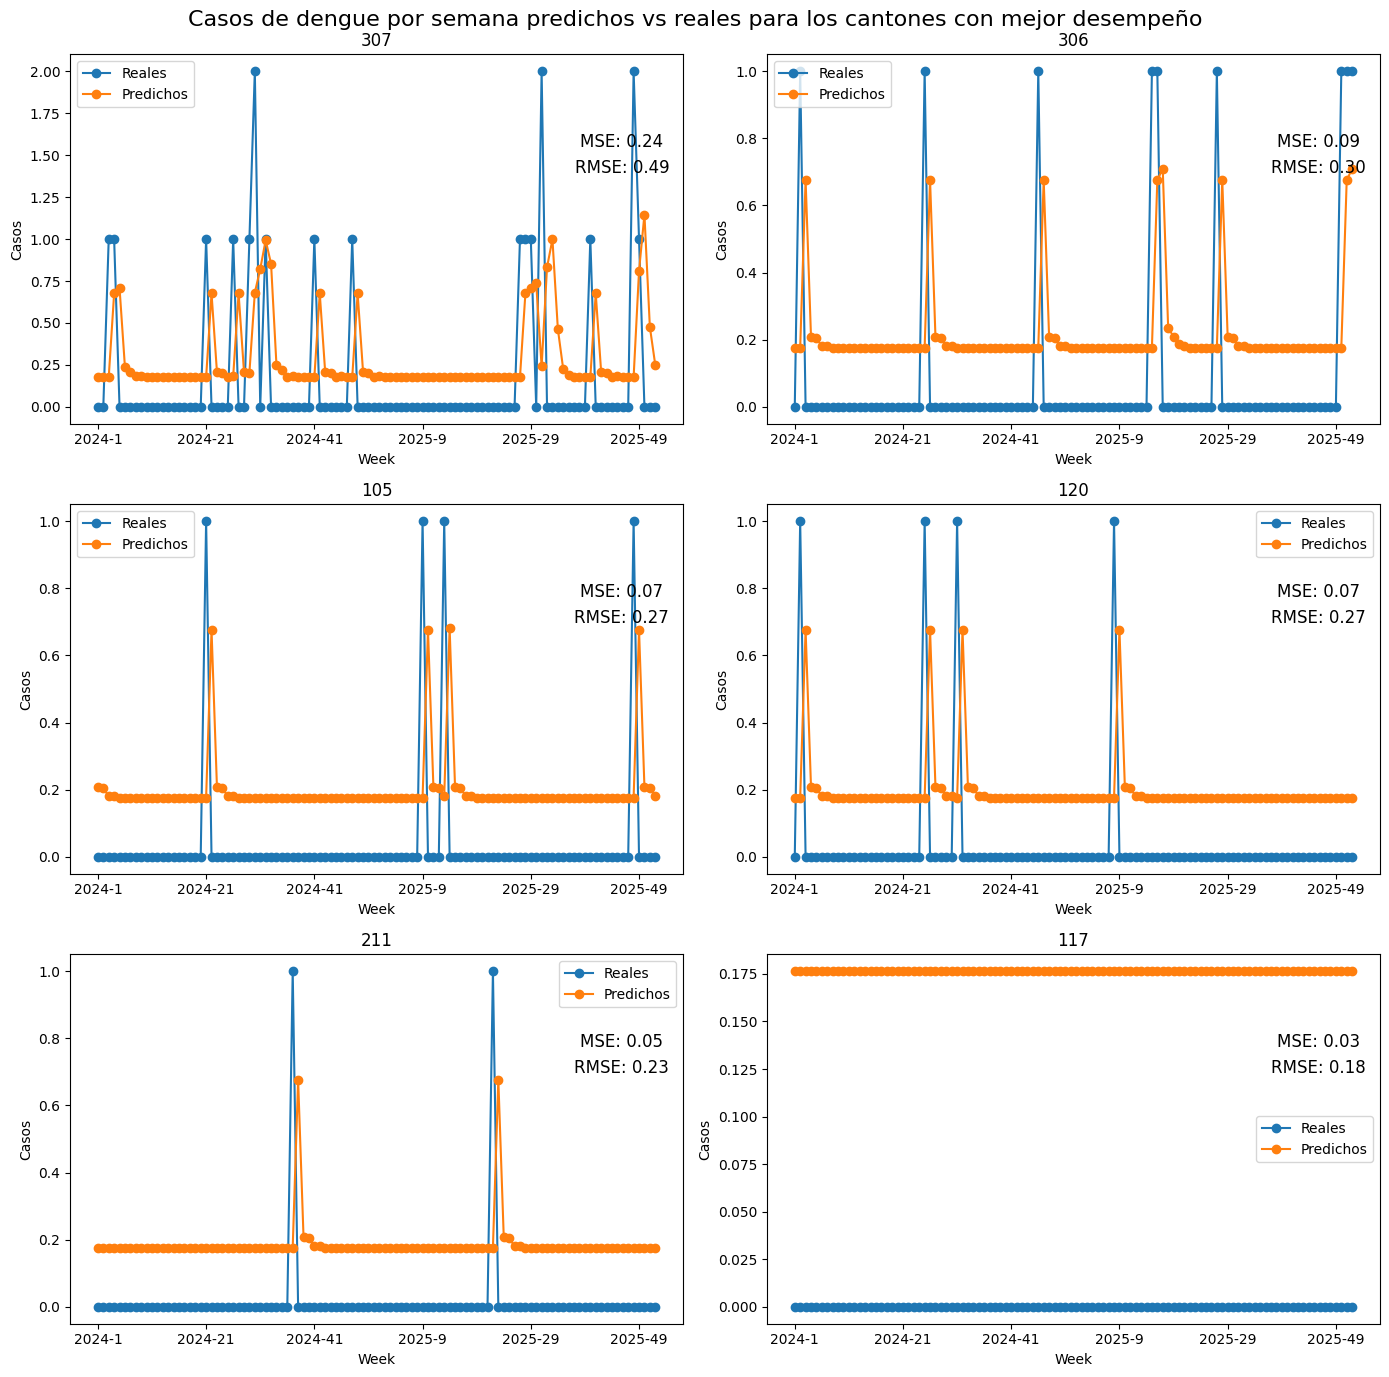

In [35]:
cases_rf_df = pd.read_csv("../../data/model_results/results_cases_rf.csv")
cases_rf_df.drop(columns = ["Unnamed: 0"], inplace = True)

cases_rf = Model(cases_rf_df)

cases_rf.plot_all("reg")

# XGBoost

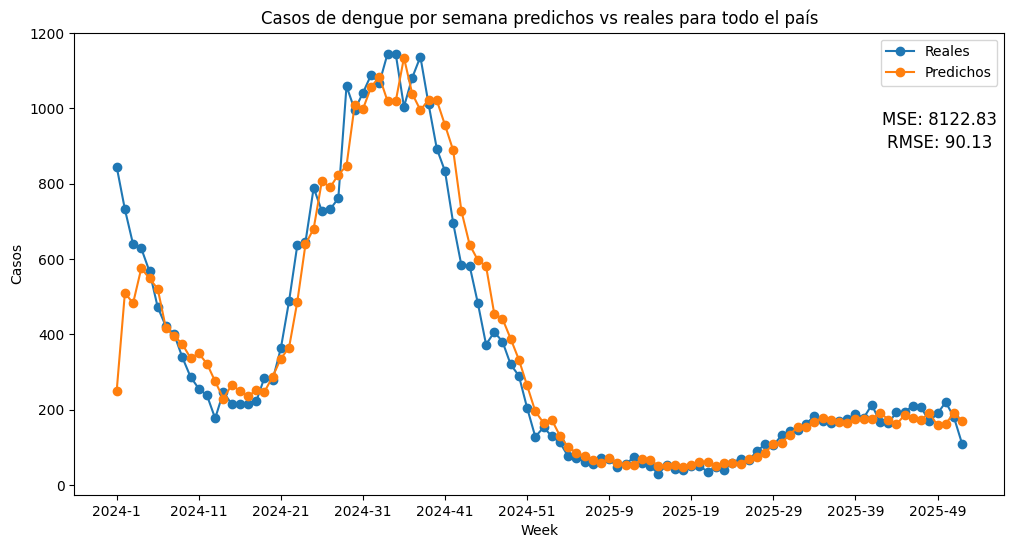

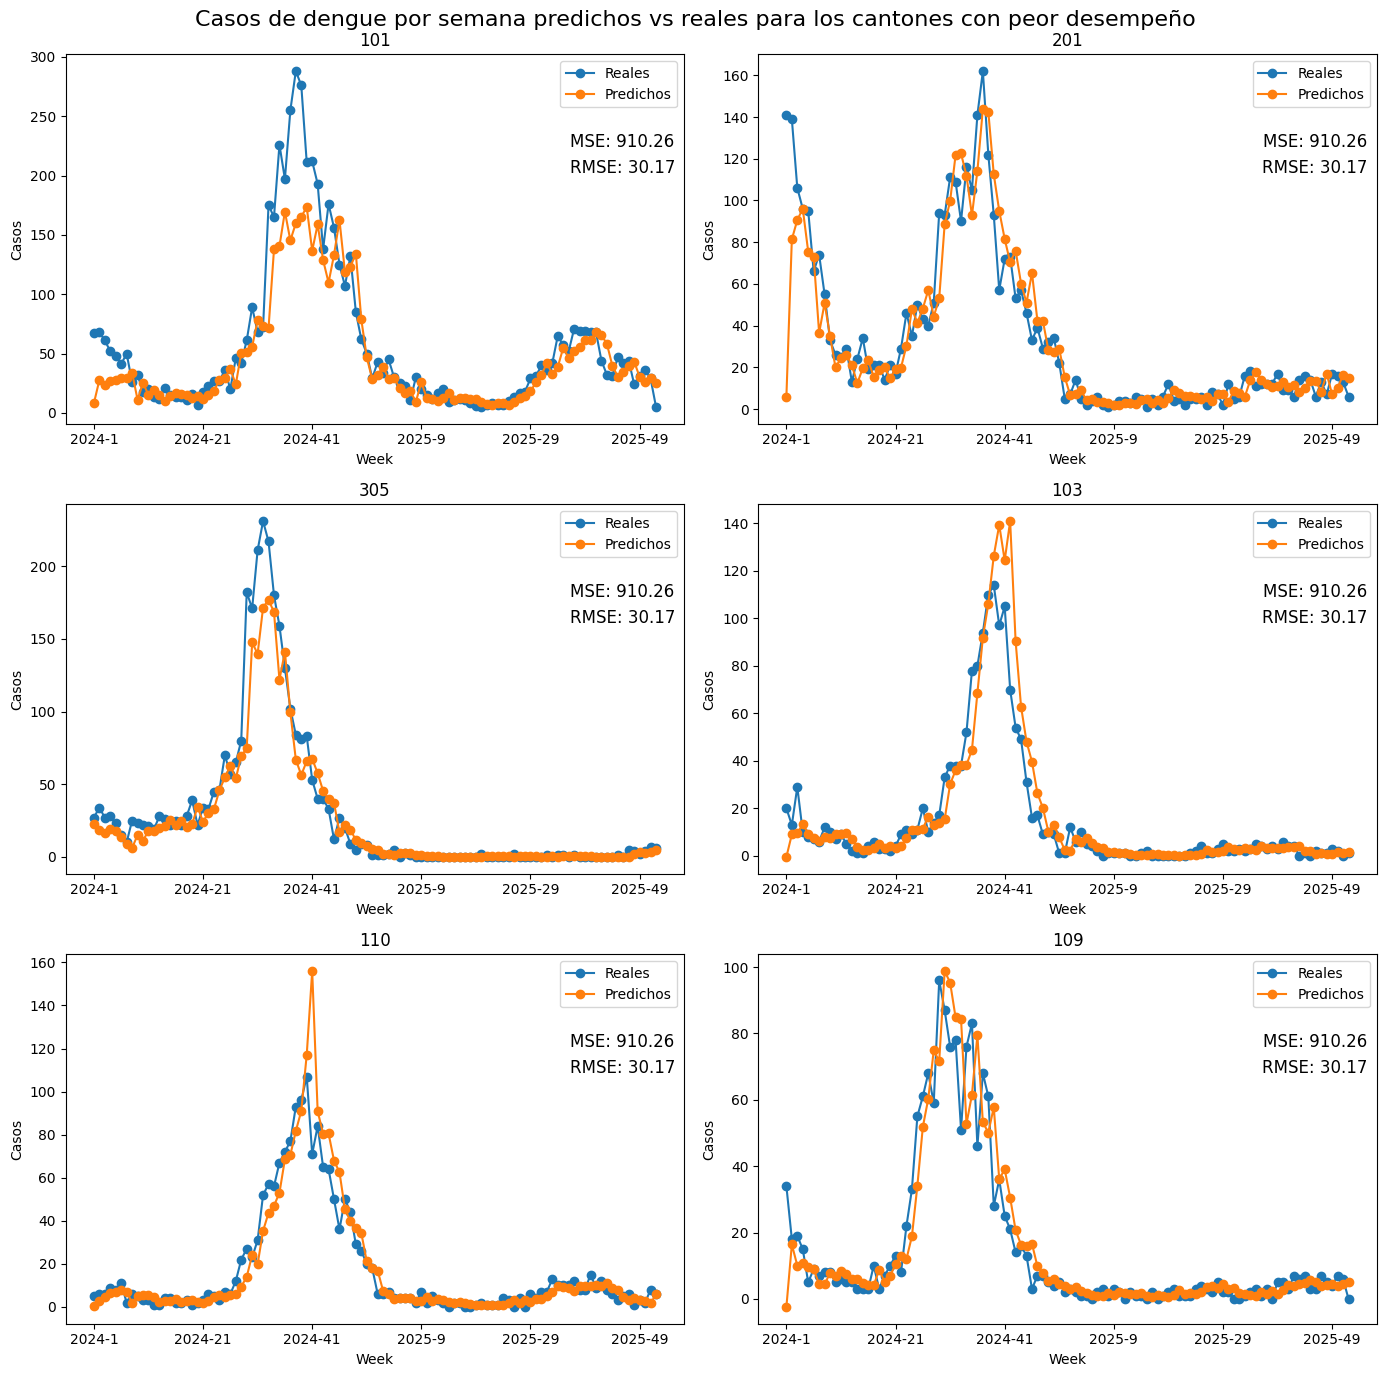

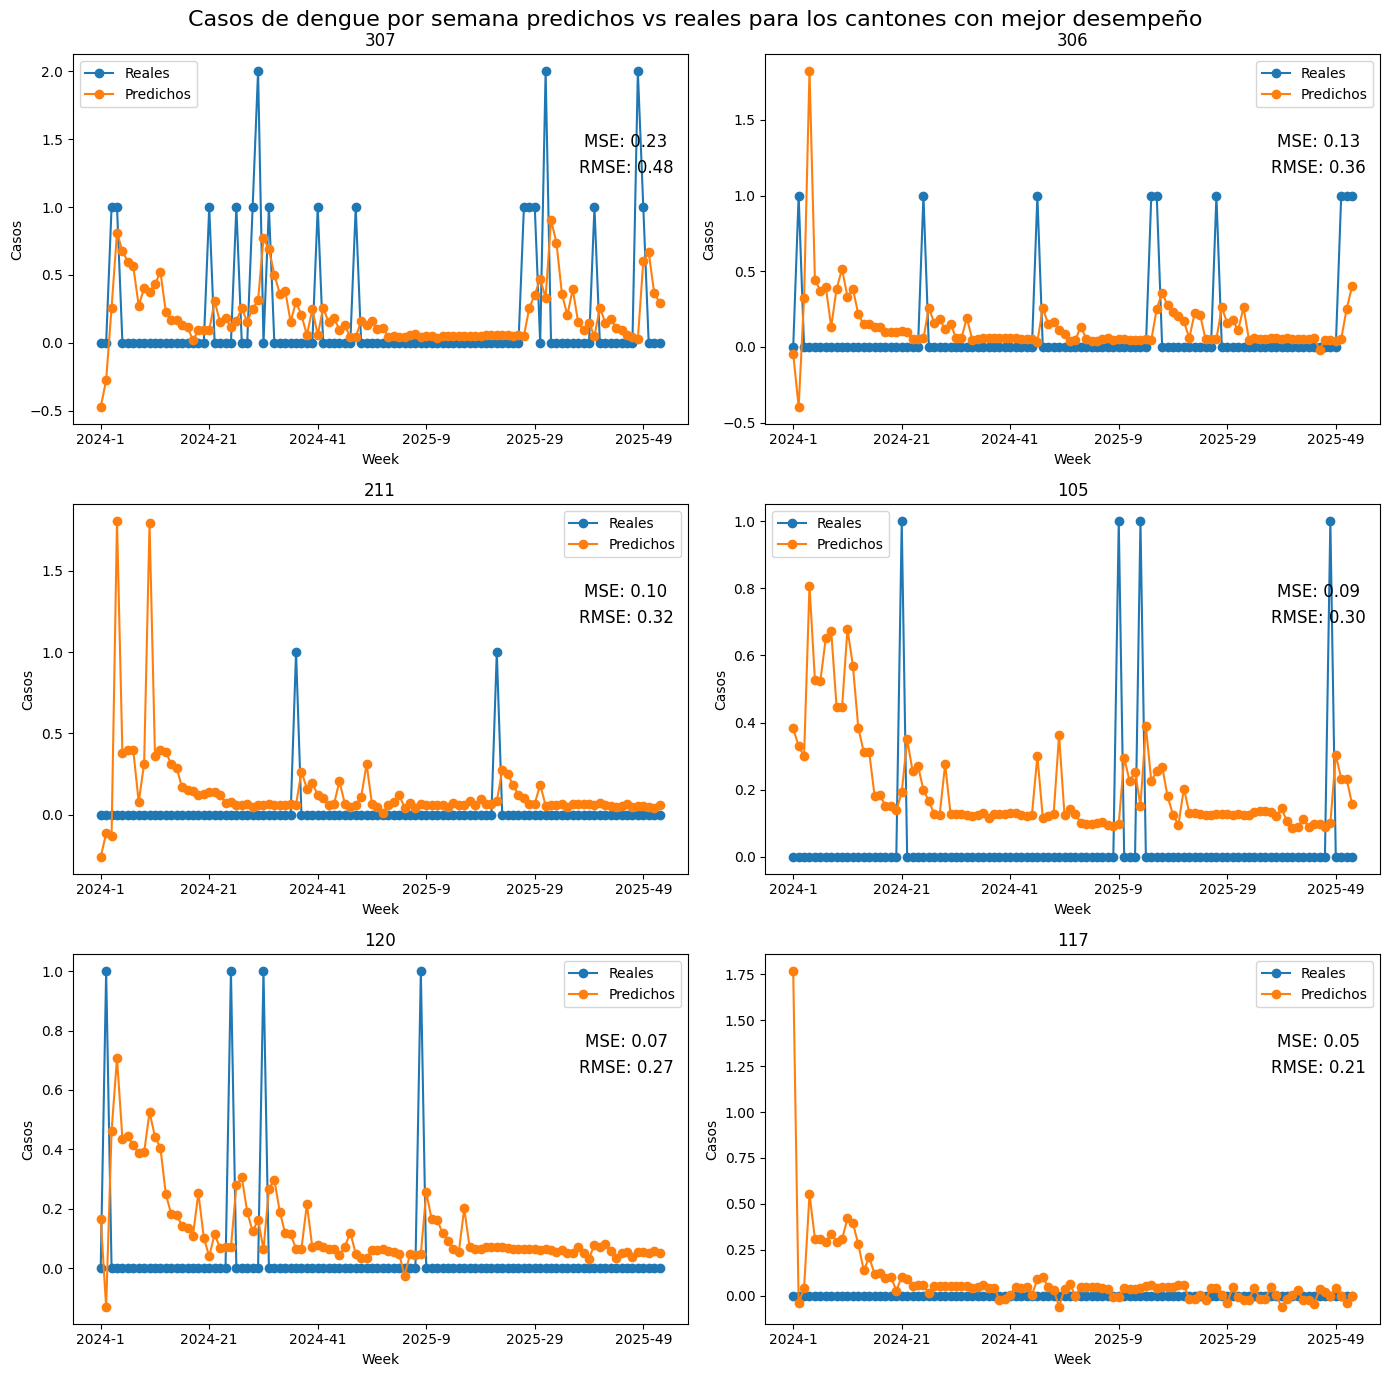

In [ ]:
cases_xgb_df = pd.read_csv("../../data/model_results/results_cases_xgb.csv")
cases_xgb_df.drop(columns = ["Unnamed: 0"], inplace = True)

cases_xgb = Model(cases_xgb_df)

cases_xgb.plot_all("reg")

# Relative Risk

## Linear Regression

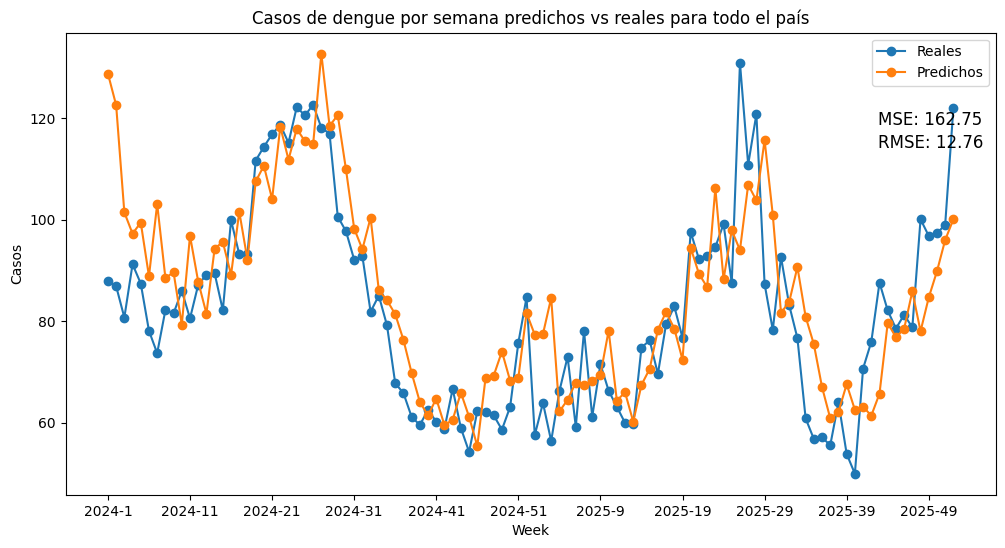

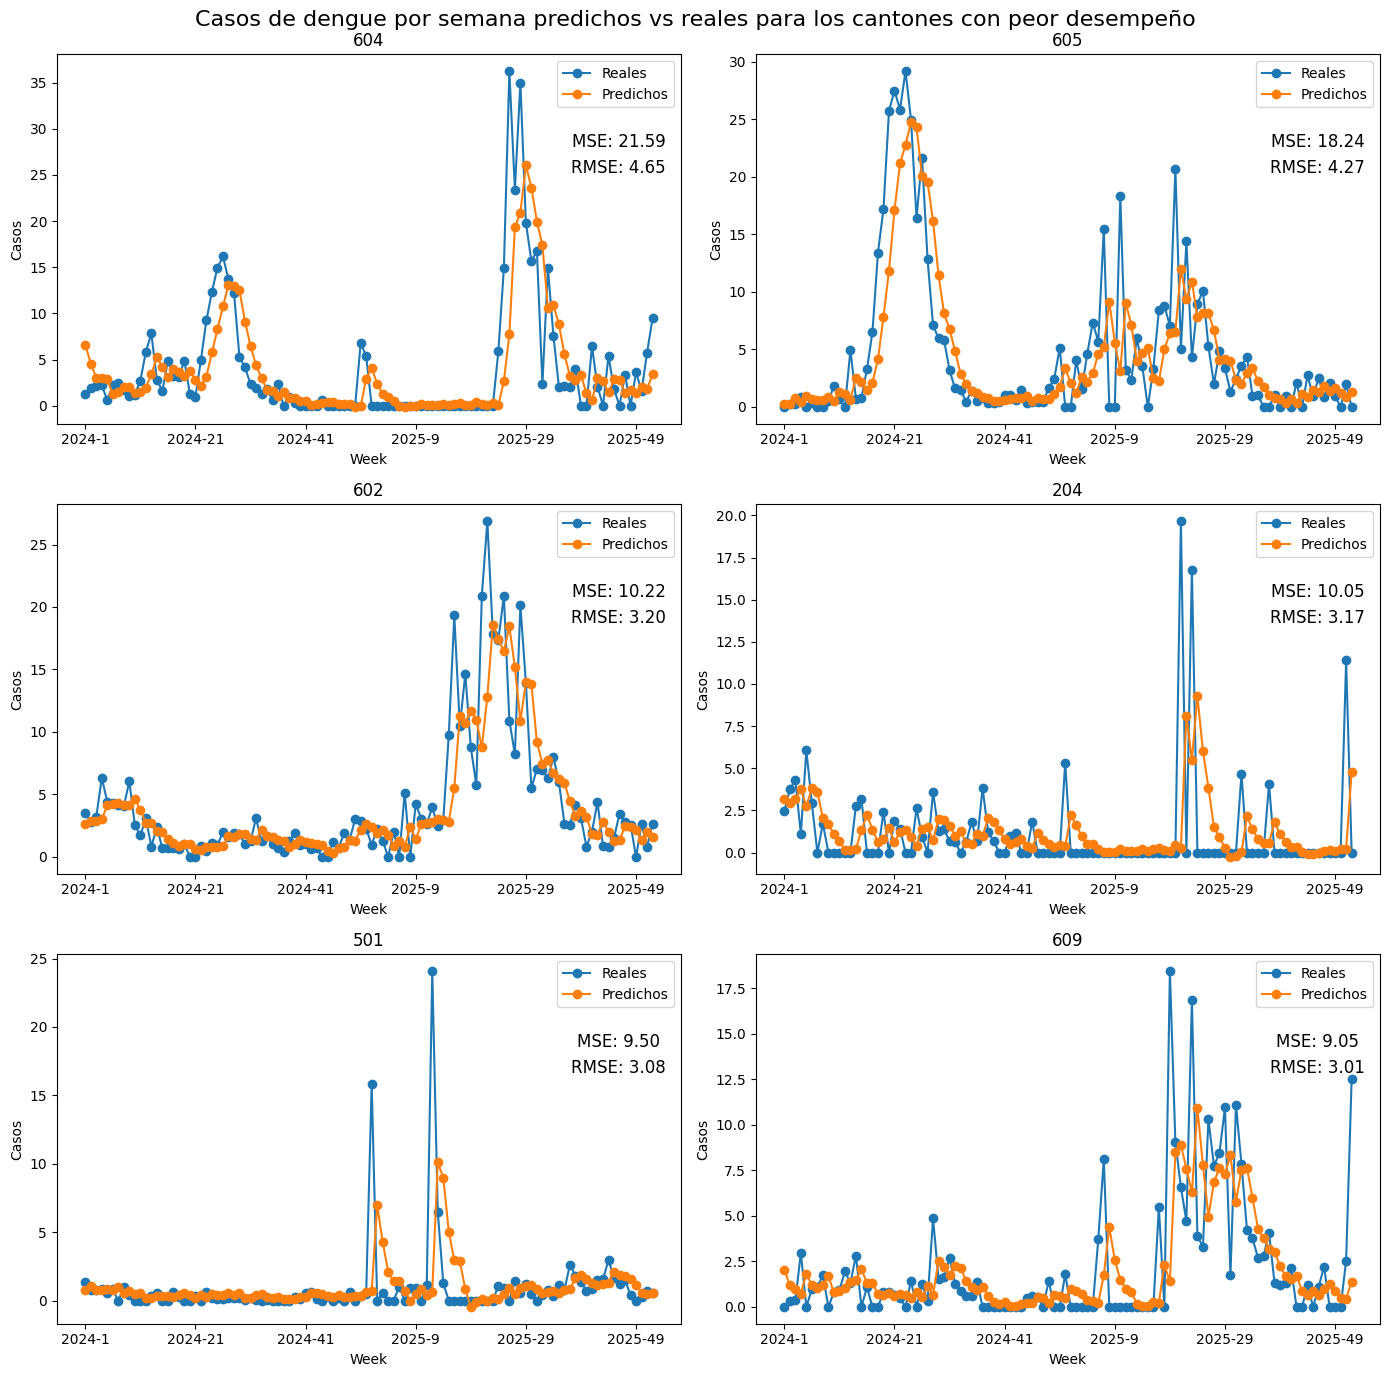

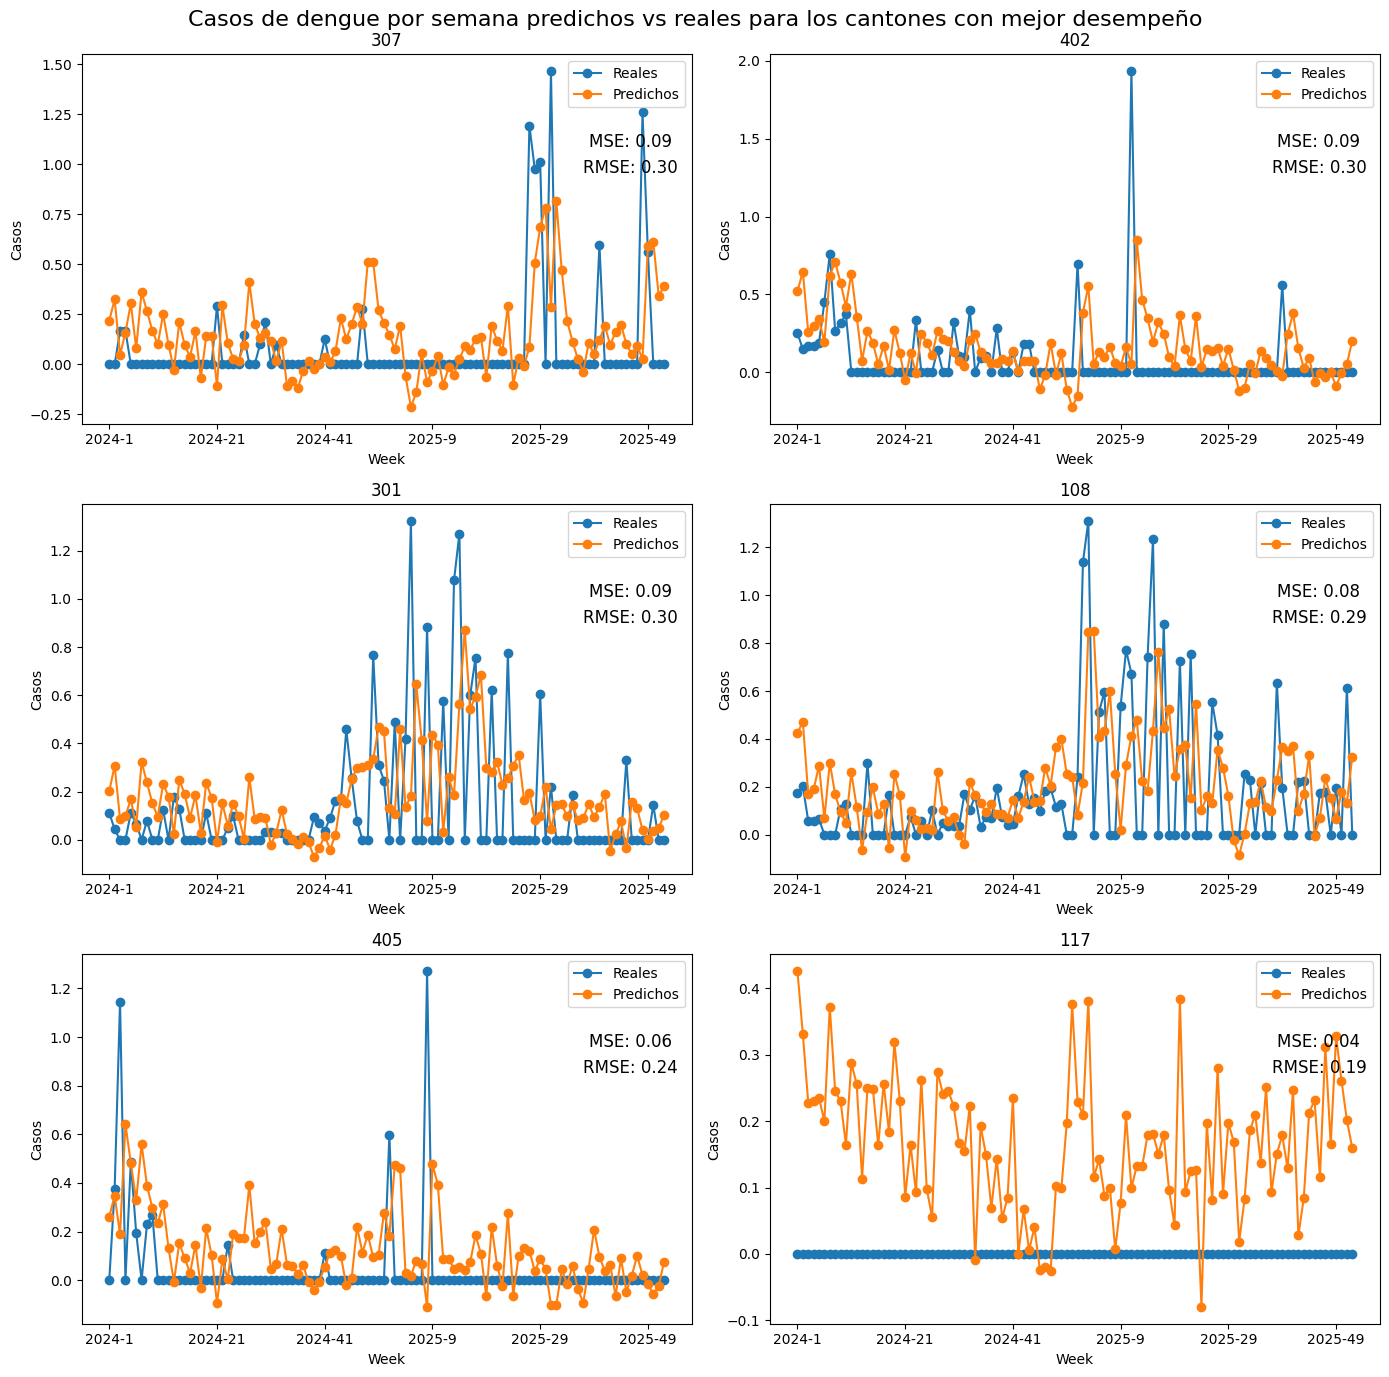

In [31]:
rr_reg_df = pd.read_csv("../../data/model_results/results_rr_reg.csv")
rr_reg_df.drop(columns = ["Unnamed: 0"], inplace = True)

rr_reg = Model(rr_reg_df)

rr_reg.plot_all("reg")

## Random Forest

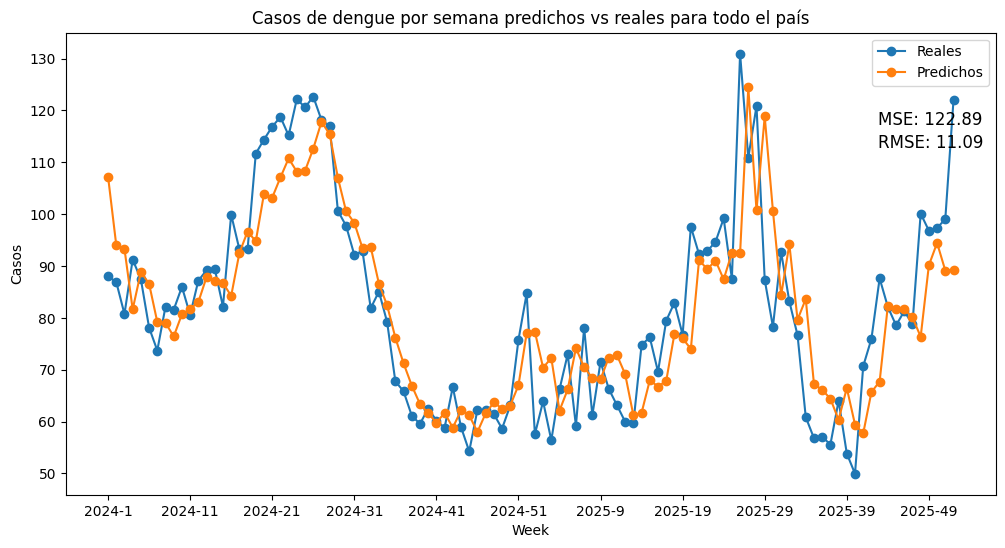

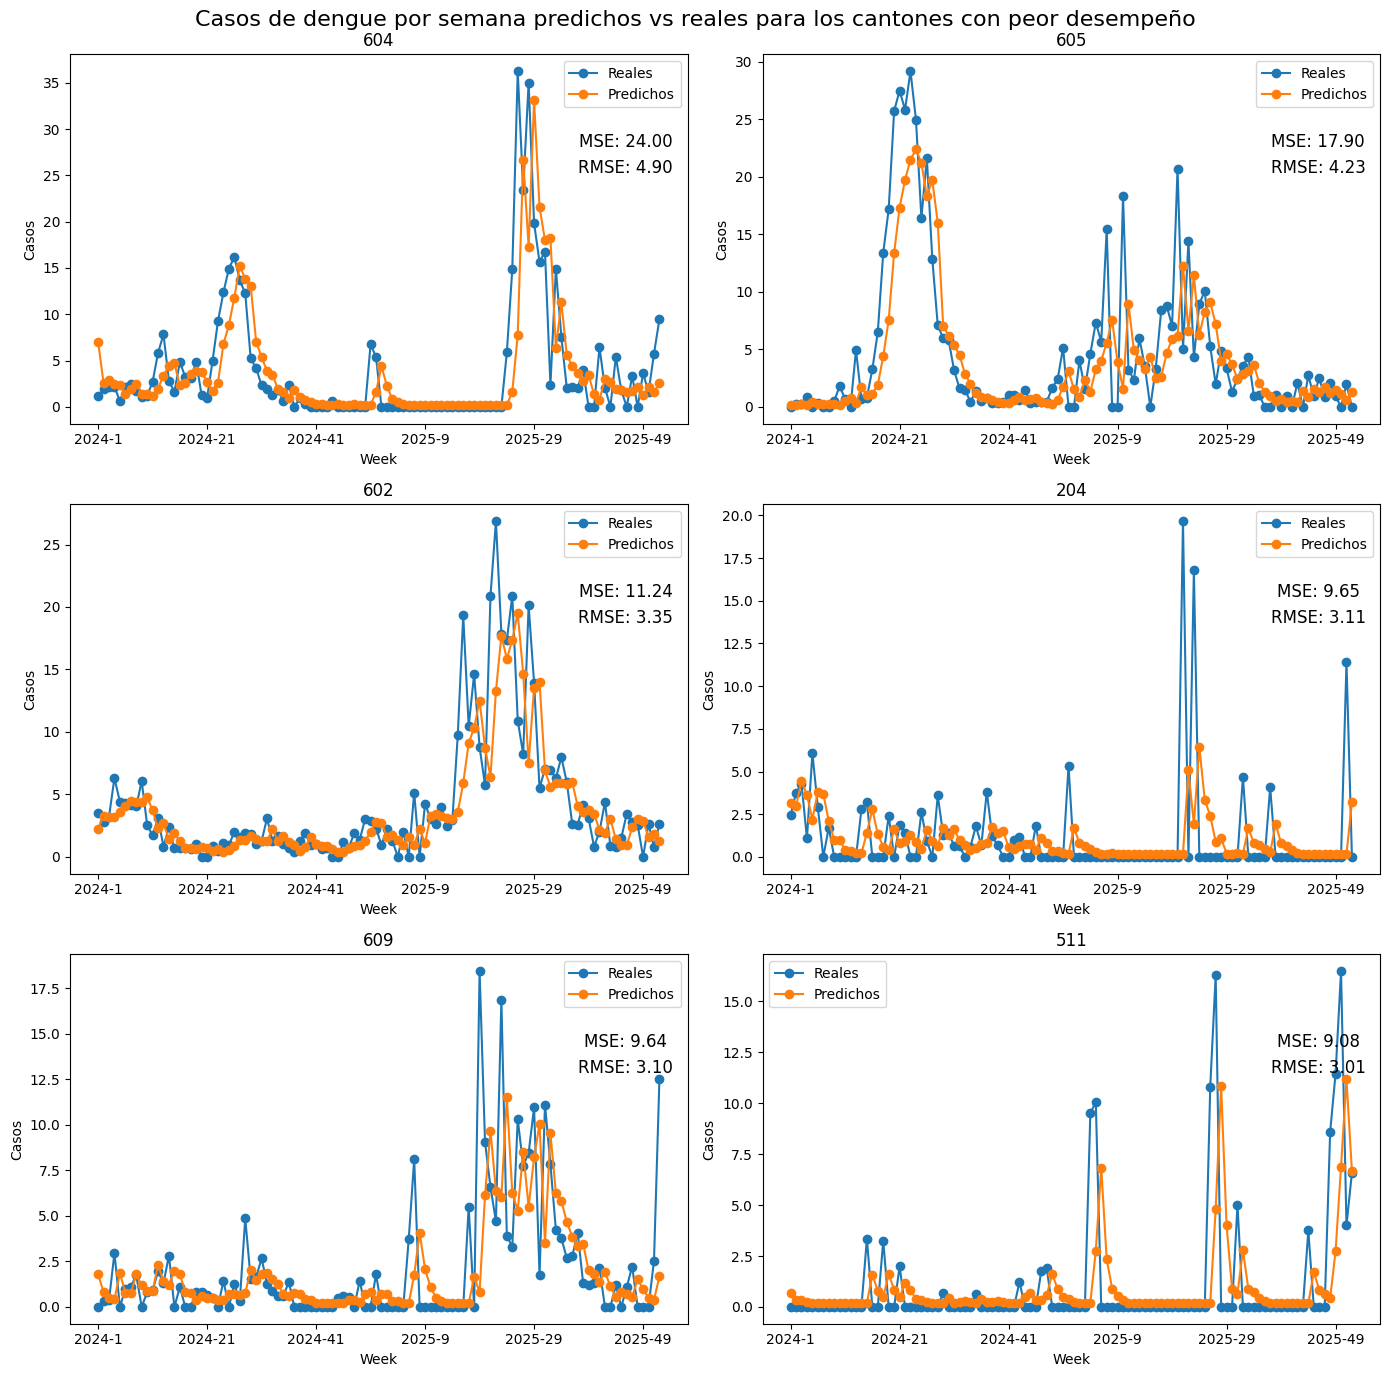

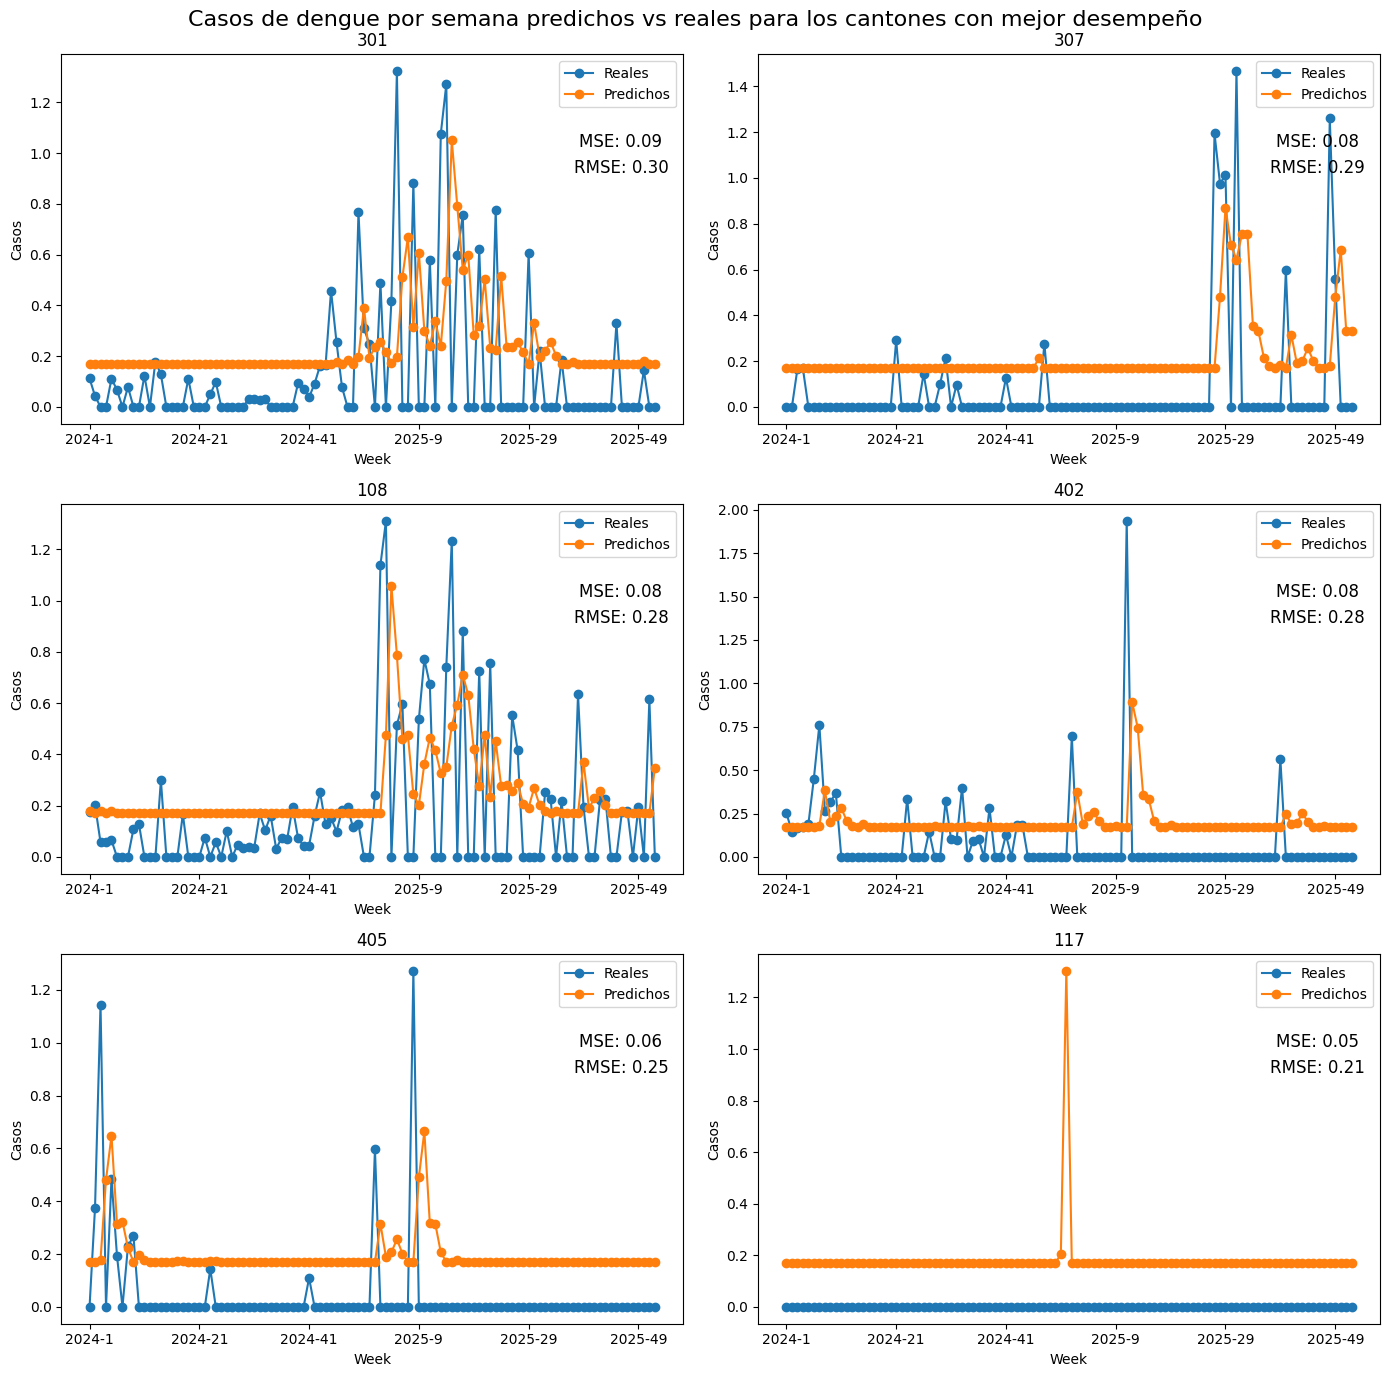

In [32]:
rr_rf_df = pd.read_csv("../../data/model_results/results_rr_rf.csv")
rr_rf_df.drop(columns = ["Unnamed: 0"], inplace = True)

rr_rf = Model(rr_rf_df)

rr_rf.plot_all("reg")

## XGBoost

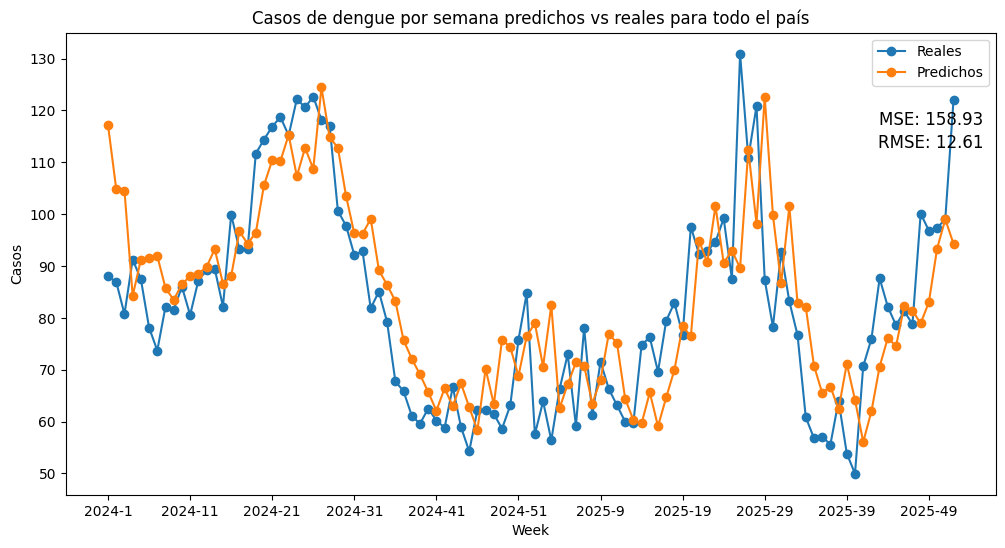

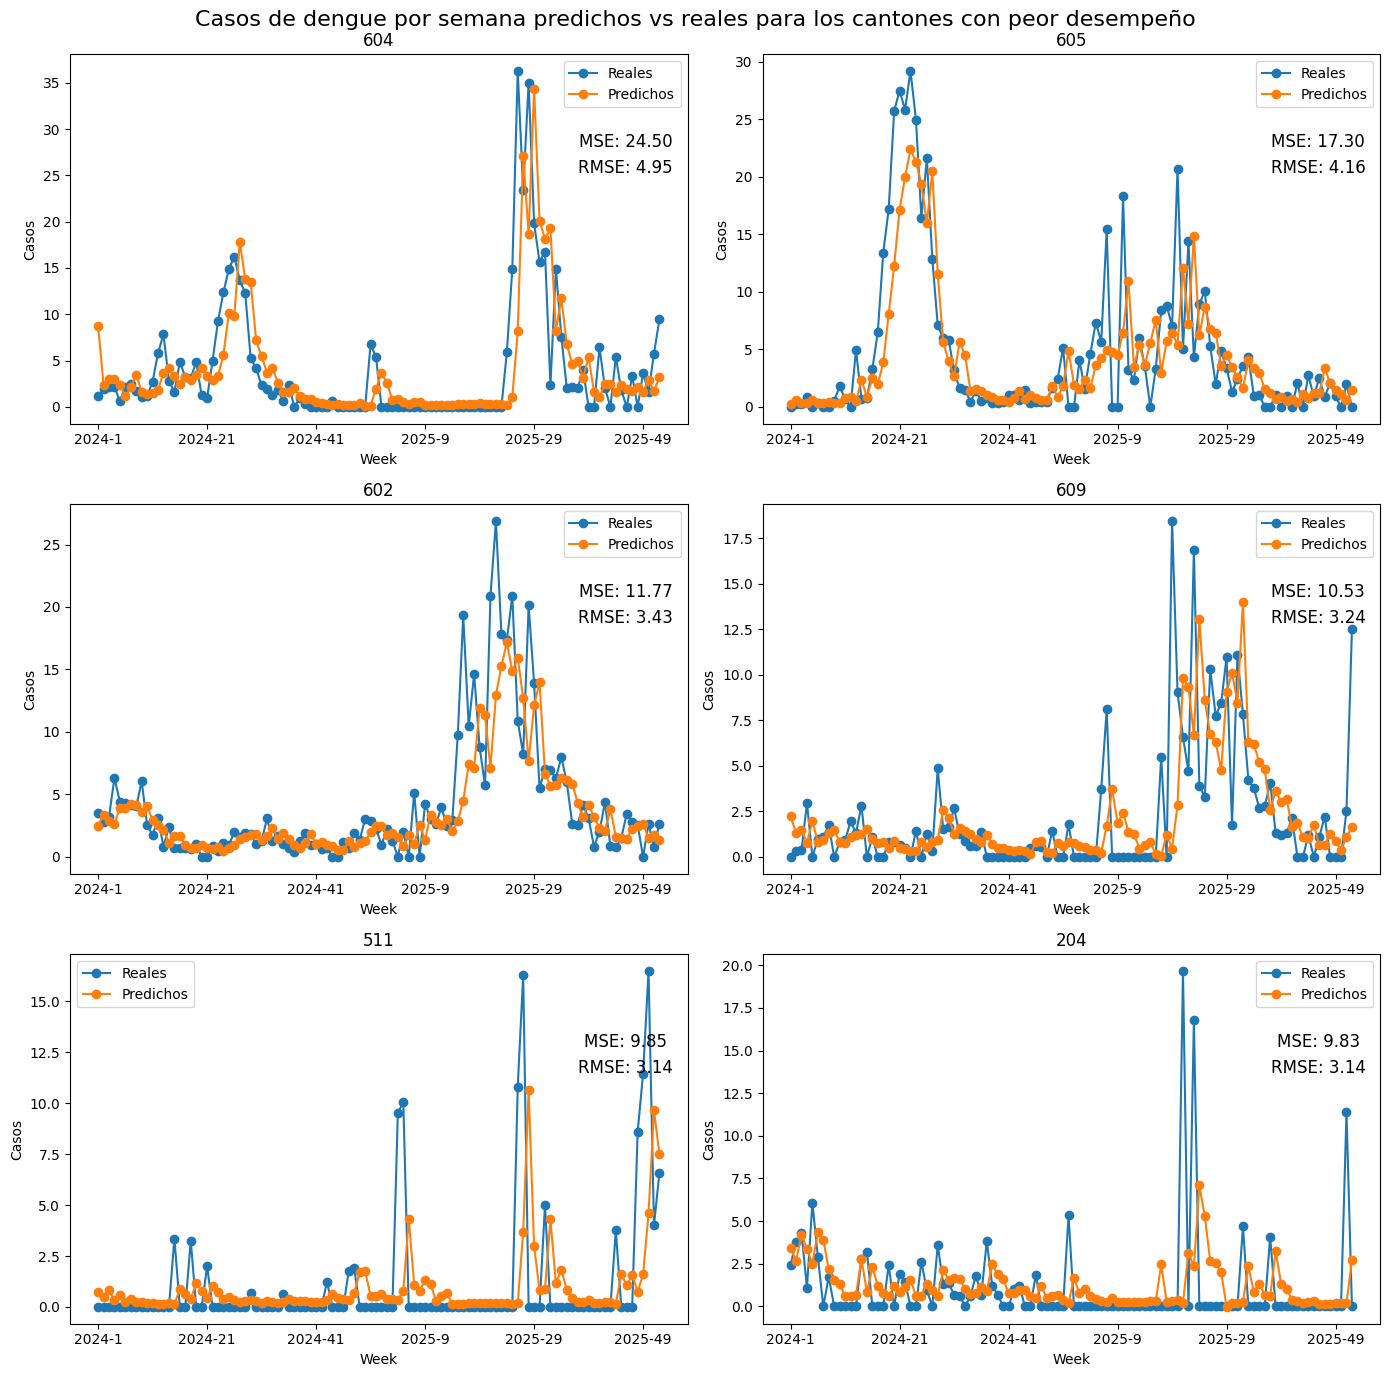

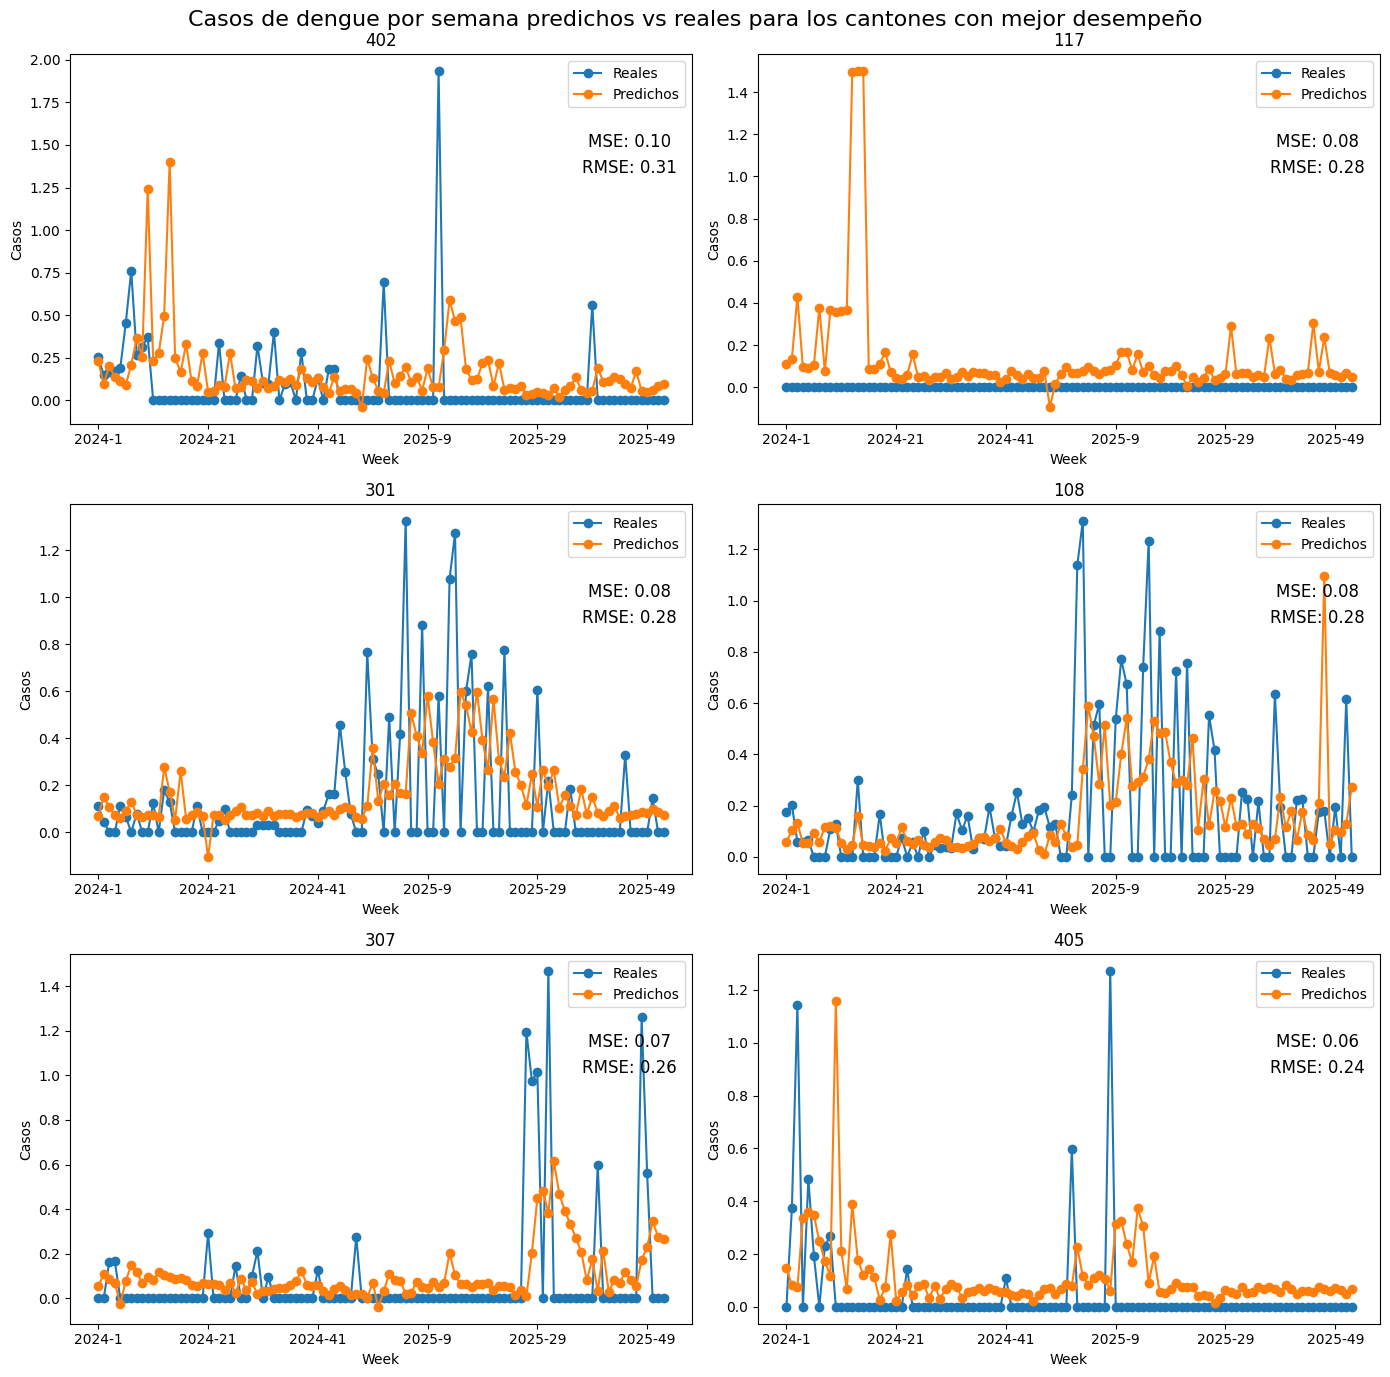

In [33]:
rr_xgb_df = pd.read_csv("../../data/model_results/results_rr_xgb.csv")
rr_xgb_df.drop(columns = ["Unnamed: 0"], inplace = True)

rr_xgb = Model(rr_xgb_df)

rr_xgb.plot_all("reg")

# Clasificación 

## Linear Regression

In [18]:
def process_classi(df):
    df[['week', 'canton']] = df['week_canton'].str.rsplit('-', n=1, expand=True)[[0, 1]]
    df.drop(columns = ["week_canton"], inplace = True)
    df_act = df.drop(columns = ["pred"])
    df_pred = df.drop(columns = ["actual"])
    week_ord = df['week'].unique()
    df['week'] = pd.Categorical(df['week'], categories=week_ord, ordered=True)
    df_act_pivot = df.pivot(index='week', columns='canton', values='actual').reset_index()
    df_pred_pivot = df.pivot(index='week', columns='canton', values='pred').reset_index()

    return df_act_pivot, df_pred_pivot

def calcular_metricas_classi(df_act_pivot, df_pred_pivot):
    cols = df_act_pivot.columns[1:]
    metric_canton = (df_act_pivot[cols] == df_pred_pivot[cols]).mean() * 100
    metric_canton = metric_canton.sort_values(ascending=False)
    return metric_canton

def top_graphs_classi(df_act_pivot, df_pred_pivot, canton, metric):
    cnf_matrix_canton = confusion_matrix(df_act_pivot[canton], df_pred_pivot[canton])

    fig, ax = plt.subplots(figsize=(6, 6))

    disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matrix_canton)
    disp.plot(ax=ax, cmap="Blues")
    ax.set_title(f"{canton} - Aciertos: {metric:.2f}%", pad=20)
    plt.tight_layout()
    plt.show()

In [26]:
clasi_rr_reg_df = pd.read_csv("../../data/model_results/results_clasi_rr_reg.csv")
clasi_rr_reg_df.drop(columns = ["Unnamed: 0"], inplace = True)
clasi_rr_reg_df["actual"] = clasi_rr_reg_df["actual"].astype("category")
clasi_rr_reg_df["pred"] = clasi_rr_reg_df["pred"].astype("category")

clasi_rr_reg = Model(clasi_rr_reg_df)
clasi_rr_reg.plot_all("classi")

TypeError: Model.get_tops() missing 1 required positional argument: 'var_type'

In [15]:
clasi_rr_reg_act_pivot[tail_5[0]],

(0      Medio
 1      Medio
 2      Medio
 3      Medio
 4      Medio
        ...  
 99     Medio
 100    Medio
 101     Bajo
 102     Bajo
 103     Alto
 Name: 401, Length: 104, dtype: category
 Categories (3, str): ['Alto', 'Bajo', 'Medio'],)

## Random Forest

clasi_rr_rf_df = pd.read_csv("../../data/model_results_clasi_rr_rf.csv")
clasi_rr_rf_df.drop(columns = ["Unnamed: 0"], inplace = True)

clasi_rr_rf = Model(clasi_rr_rf_df)

clasi_rr_rf.plot_all("classi")

## XGBoost

In [ ]:
clasi_rr_xgb_df = pd.read_csv("../../data/model_results_clasi_rr_xgb.csv")
clasi_rr_xgb_df.drop(columns = ["Unnamed: 0"], inplace = True)

clasi_rr_xgb = Model(clasi_rr_xgb_df)

clasi_rr_xgb.plot_all("classi")

# Clasificación (sin ceros)

## Linear Regression

In [ ]:
clasi_rr_no_0_reg_df = pd.read_csv("../../data/model_results_clasi_rr_no_0_reg.csv")
clasi_rr_no_0_reg_df.drop(columns = ["Unnamed: 0"], inplace = True)

clasi_rr_no_0_reg = Model(clasi_rr_no_0_reg_df)

clasi_rr_no_0_reg.plot_all("classi")

## Random Forest

In [ ]:
clasi_rr_no_0_rf_df = pd.read_csv("../../data/model_results_clasi_rr_no_0_rf.csv")
clasi_rr_no_0_rf_df.drop(columns = ["Unnamed: 0"], inplace = True)

clasi_rr_no_0_rf = Model(clasi_rr_no_0_rf_df)

clasi_rr_no_0_rf.plot_all("classi")

## XGBoost

In [ ]:
clasi_rr_no_0_xgb_df = pd.read_csv("../../data/model_results_clasi_rr_no_0_xgb.csv")
clasi_rr_no_0_xgb_df.drop(columns = ["Unnamed: 0"], inplace = True)

clasi_rr_no_0_xgb = Model(clasi_rr_no_0_xgb_df)

clasi_rr_no_0_rf.plot_all("classi")

## Draft

In [ ]:
# cases_reg = pd.read_csv("../../data/model_results/results_cases_reg.csv")
# cases_reg.drop(columns = ["Unnamed: 0"], inplace = True)


In [ ]:
# cases_reg.head()

In [ ]:
# cases_reg[['week', 'canton']] = cases_reg['week_canton'].str.rsplit('-', n=1, expand=True)[[0, 1]]
# cases_reg.drop(columns = ["week_canton"], inplace = True)

In [ ]:
# cases_reg.head()

In [ ]:
# cases_reg_act = cases_reg.drop(columns = ["pred"])
# cases_reg_pred = cases_reg.drop(columns = ["actual"])

In [ ]:
# week_ord = cases_reg['week'].unique()

# cases_reg['week'] = pd.Categorical(cases_reg['week'], categories=week_ord, ordered=True)

In [ ]:
# cases_reg_act_pivot = cases_reg.pivot(index='week', columns='canton', values='actual').reset_index()
# cases_reg_pred_pivot = cases_reg.pivot(index='week', columns='canton', values='pred').reset_index()

In [ ]:
# cases_reg_act_pivot.columns

In [ ]:
# cases_reg_act_pivot["total"] = cases_reg_act_pivot.drop(columns="week").sum(axis=1)
# cases_reg_pred_pivot["total"] = cases_reg_pred_pivot.drop(columns="week").sum(axis=1)

In [ ]:
# cases_reg_act_pivot

In [ ]:
# cases_reg_pred_pivot

In [ ]:
# fig, ax = plt.subplots(figsize=(12, 6))

# def ticks_years(n):
#     [l.set_visible(False) for (i,l) in enumerate(ax.xaxis.get_ticklabels()) if i % n != 0]
#     for i, tick in enumerate(ax.xaxis.get_major_ticks()):
#         if i % n != 0:
#             tick.tick1line.set_visible(False)
#             tick.tick2line.set_visible(False)
#             tick.gridline.set_visible(False) 

# ax.plot(cases_reg_act_pivot['week'], cases_reg_act_pivot['total'], label='Reales', marker='o')
# ax.plot(cases_reg_pred_pivot['week'], cases_reg_pred_pivot['total'], label='Predichos', marker='o')
# ticks_years(10)
# ax.set_xlabel('Week')
# ax.set_ylabel('Casos')
# mse = ((cases_reg_act_pivot["total"] - cases_reg_pred_pivot["total"])**2).mean()
# ax.text(0.93, 0.8, f'MSE: {mse:.2f}', transform=ax.transAxes, ha='center', fontsize=12)
# ax.text(0.93, 0.75, f'RMSE: {mse**0.5:.2f}', transform=ax.transAxes, ha='center', fontsize=12)
# ax.legend()
# ax.set_title('Casos de dengue por semana predichos vs reales para todo el país')

In [ ]:
# cols = cases_reg_act_pivot.columns[1:-1]

# mse_canton = ((cases_reg_act_pivot[cols] - cases_reg_pred_pivot[cols])**2).mean()

# mse_canton.head()

In [ ]:
# mse_canton = mse_canton.sort_values(ascending=False)

In [ ]:
# head_5 = mse_canton.head(6).keys()
# tail_5 = mse_canton.tail(6).keys()

# mse_top_5 = mse_canton.head(6).values
# mse_tail_5 = mse_canton.tail(6).values

In [ ]:
# mse_canton.head(6)

In [ ]:
# mse_canton.tail(6)

In [ ]:
# fig, ax = plt.subplots(3, 2, figsize=(14, 14))

# def ticks_years_top(x, y, n):
#     [l.set_visible(False) for (i,l) in enumerate(ax[x, y].xaxis.get_ticklabels()) if i % n != 0]
#     for i, tick in enumerate(ax[x, y].xaxis.get_major_ticks()):
#         if i % n != 0:
#             tick.tick1line.set_visible(False)
#             tick.tick2line.set_visible(False)
#             tick.gridline.set_visible(False) 

# def top_graphs(x, y, canton, mse):
#     ax[x, y].plot(cases_reg_act_pivot['week'], cases_reg_act_pivot[canton], label='Reales', marker='o')
#     ax[x, y].plot(cases_reg_pred_pivot['week'], cases_reg_pred_pivot[canton], label='Predichos', marker='o')
#     ticks_years_top(x, y, 20)
#     ax[x, y].set_xlabel('Week')
#     ax[x, y].set_ylabel('Casos')
#     ax[x, y].text(0.9, 0.75, f'MSE: {mse:.2f}', transform=ax[x, y].transAxes, ha='center', fontsize=12)
#     ax[x, y].text(0.9, 0.68, f'RMSE: {mse**0.5:.2f}', transform=ax[x, y].transAxes, ha='center', fontsize=12)
#     ax[x, y].legend()
#     ax[x, y].set_title(canton)

# top_graphs(0, 0, head_5[0], mse_top_5[0])
# top_graphs(0, 1, head_5[1], mse_top_5[0])
# top_graphs(1, 0, head_5[2], mse_top_5[0])
# top_graphs(1, 1, head_5[3], mse_top_5[0])
# top_graphs(2, 0, head_5[4], mse_top_5[0])
# top_graphs(2, 1, head_5[5], mse_top_5[0])
# fig.tight_layout()

In [ ]:
# fig, ax = plt.subplots(3, 2, figsize=(14, 14))

# top_graphs(0, 0, tail_5[0], mse_tail_5[0])
# top_graphs(0, 1, tail_5[1], mse_tail_5[1])
# top_graphs(1, 0, tail_5[2], mse_tail_5[2])
# top_graphs(1, 1, tail_5[3], mse_tail_5[3])
# top_graphs(2, 0, tail_5[4], mse_tail_5[4])
# top_graphs(2, 1, tail_5[5], mse_tail_5[5])
# fig.tight_layout()